# Phase 2 — andito subset: FAISS index + metadata

Mirrors `phase2_faiss.ipynb`. Builds a `faiss.IndexFlatIP(512)` over the clean andito CLIP embeddings and writes an aligned metadata pickle whose schema **matches** `embeddings/faiss_metadata_clean.pkl` exactly so `phase_test_andito.ipynb` can run as a drop-in twin of `phase_test.ipynb`.

Inputs:
- `embeddings/andito_image_features_clean.pt` (from `phase0_andito.ipynb`)
- `embeddings/andito_image_paths_clean.pkl`
- `../dataset/andito_landmarks_registry.csv` (from `build_andito_subset_registry.py`)

Outputs:
- `embeddings/andito_faiss_index_clean.bin`
- `embeddings/andito_faiss_metadata_clean.pkl`

In [1]:
# ── Environment guards ────────────────────────────────────────────────────────
import os
os.environ["OMP_NUM_THREADS"]             = "1"
os.environ["MKL_NUM_THREADS"]             = "1"
os.environ["VECLIB_MAXIMUM_THREADS"]      = "1"
os.environ["NUMEXPR_NUM_THREADS"]         = "1"
os.environ["KMP_DUPLICATE_LIB_OK"]        = "TRUE"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["TOKENIZERS_PARALLELISM"]      = "false"
os.environ["KMP_INIT_AT_FORK"]            = "FALSE"

import csv, pickle
import numpy as np

import torch
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

import faiss
import clip
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

device = "mps" if torch.backends.mps.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
model.eval()
print(f"CLIP loaded on {device}")
print(f"FAISS {faiss.__version__} | NumPy {np.__version__} | PyTorch {torch.__version__}")

CLIP loaded on mps
FAISS 1.13.2 | NumPy 2.4.3 | PyTorch 2.10.0


## 1. Load the clean andito embeddings

In [2]:
image_features = torch.load("embeddings/andito_image_features_clean.pt", weights_only=True)

with open("embeddings/andito_image_paths_clean.pkl", "rb") as f:
    image_paths = pickle.load(f)

print(f"Loaded {len(image_paths)} clean andito embeddings, shape: {image_features.shape}")

# All CLIP embeddings should be L2-normalised — required for IP == cosine.
norms = image_features.norm(dim=-1)
print(f"Embedding norms  min={norms.min():.4f}  max={norms.max():.4f}  mean={norms.mean():.4f}")

Loaded 3751 clean andito embeddings, shape: torch.Size([3751, 512])
Embedding norms  min=0.9995  max=1.0010  mean=1.0000


## 2. Load the andito registry and build per-image metadata

The registry is keyed by `canonical_name` — the same sanitization used when the Colab loop saved each image filename (`{rownum}_{sanitized_name}.jpg`). For each image we strip the leading `<rownum>_` and the `.jpg` suffix to recover the canonical_name.

In [3]:
REGISTRY_PATH = "../dataset/andito_landmarks_registry.csv"

registry = {}
with open(REGISTRY_PATH, newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        registry[row["canonical_name"]] = row

print(f"Registry loaded: {len(registry)} unique landmarks")

def canonical_from_path(path: str) -> str:
    """Recover canonical_name from a flat-dir filename like '791_Great_Pyramid_of_Giza.jpg'.
    Strips the numeric prefix and the .jpg extension.
    """
    base = os.path.basename(path).rsplit(".", 1)[0]
    head, sep, tail = base.partition("_")
    # head is the rownum, tail is the sanitized name. If parse failed, fall back to base.
    return tail if (sep and head.isdigit()) else base

metadata = []
missing  = 0
for path in image_paths:
    canonical = canonical_from_path(path)
    rec = registry.get(canonical, {})
    if not rec:
        missing += 1
    metadata.append({
        "image_path":          path,
        "landmark_name":       canonical,
        "landmark_type":       rec.get("landmark_type",       "Unknown"),
        "historical_era":      rec.get("historical_era",      "Unknown"),
        "geographic_region":   rec.get("geographic_region",   "Unknown"),
        "city":                rec.get("city",                "Unknown"),
        "architectural_style": rec.get("architectural_style", "Unknown"),
        "coordinates_lat":     rec.get("coordinates_lat",     ""),
        "coordinates_lon":     rec.get("coordinates_lon",     ""),
    })

print(f"Metadata built: {len(metadata)} entries  ({missing} without registry match)")

Registry loaded: 113 unique landmarks
Metadata built: 3751 entries  (0 without registry match)


## 3. Build the FAISS index

In [4]:
DIM = 512  # CLIP ViT-B/32

vectors = image_features.cpu().numpy().astype(np.float32)

index = faiss.IndexFlatIP(DIM)
index.add(vectors)

print(f"FAISS index built: {index.ntotal} vectors  (dim={DIM})")
assert index.ntotal == len(metadata) == vectors.shape[0], \
    "Misalignment between index, metadata, and feature matrix!"

FAISS index built: 3751 vectors  (dim=512)


## 4. Save the index and metadata

In [5]:
os.makedirs("embeddings", exist_ok=True)

faiss.write_index(index, "embeddings/andito_faiss_index_clean.bin")

with open("embeddings/andito_faiss_metadata_clean.pkl", "wb") as f:
    pickle.dump(metadata, f)

print(f"Saved: embeddings/andito_faiss_index_clean.bin  ({index.ntotal} vectors)")
print("Saved: embeddings/andito_faiss_metadata_clean.pkl")

Saved: embeddings/andito_faiss_index_clean.bin  (3751 vectors)
Saved: embeddings/andito_faiss_metadata_clean.pkl


## 5. Equivalence check — FAISS vs brute-force baseline

In [6]:
def encode_sketch(path: str) -> np.ndarray:
    img = preprocess(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = model.encode_image(img)
        feat /= feat.norm(dim=-1, keepdim=True)
    return feat.cpu().numpy().astype(np.float32)

SKETCH_PATH = "pyramid-mid.jpg"
q = encode_sketch(SKETCH_PATH)

faiss_scores, faiss_indices = index.search(q, 5)
print("FAISS top-5 (andito clean index):")
for score, idx in zip(faiss_scores[0], faiss_indices[0]):
    print(f"  {score:.4f}  {metadata[idx]['landmark_name']:45s}  {image_paths[idx]}")

feats_cpu = image_features.float().cpu()
sims = (torch.from_numpy(q) @ feats_cpu.T).numpy()
top_idx = sims[0].argsort()[-5:][::-1]
print("\nBrute-force top-5 (same embeddings):")
for idx in top_idx:
    print(f"  {sims[0][idx]:.4f}  {metadata[idx]['landmark_name']:45s}  {image_paths[idx]}")

assert faiss_indices[0].tolist() == top_idx.tolist(), "Mismatch — index may be misaligned!"
print("\nFAISS results match brute-force baseline.")

FAISS top-5 (andito clean index):
  0.7902  This_appears_to_be_related_to_Pyramid_of_Djedefra  egyptian_landmarks_data/images/923609_This_appears_to_be_related_to_Pyramid_of_Djedefra.jpg
  0.7585  Funerary_Temple_of_Khafre                      egyptian_landmarks_data/images/536400_Funerary_Temple_of_Khafre.jpg
  0.7487  Funerary_Temple_of_Khafre                      egyptian_landmarks_data/images/9362_Funerary_Temple_of_Khafre.jpg
  0.7424  Funerary_Temple_of_Khafre                      egyptian_landmarks_data/images/720953_Funerary_Temple_of_Khafre.jpg
  0.7414  Funerary_Temple_of_Khafre                      egyptian_landmarks_data/images/1106066_Funerary_Temple_of_Khafre.jpg

Brute-force top-5 (same embeddings):
  0.7902  This_appears_to_be_related_to_Pyramid_of_Djedefra  egyptian_landmarks_data/images/923609_This_appears_to_be_related_to_Pyramid_of_Djedefra.jpg
  0.7585  Funerary_Temple_of_Khafre                      egyptian_landmarks_data/images/536400_Funerary_Temple_of_Khafre.jp

## 6. Quick visual sanity

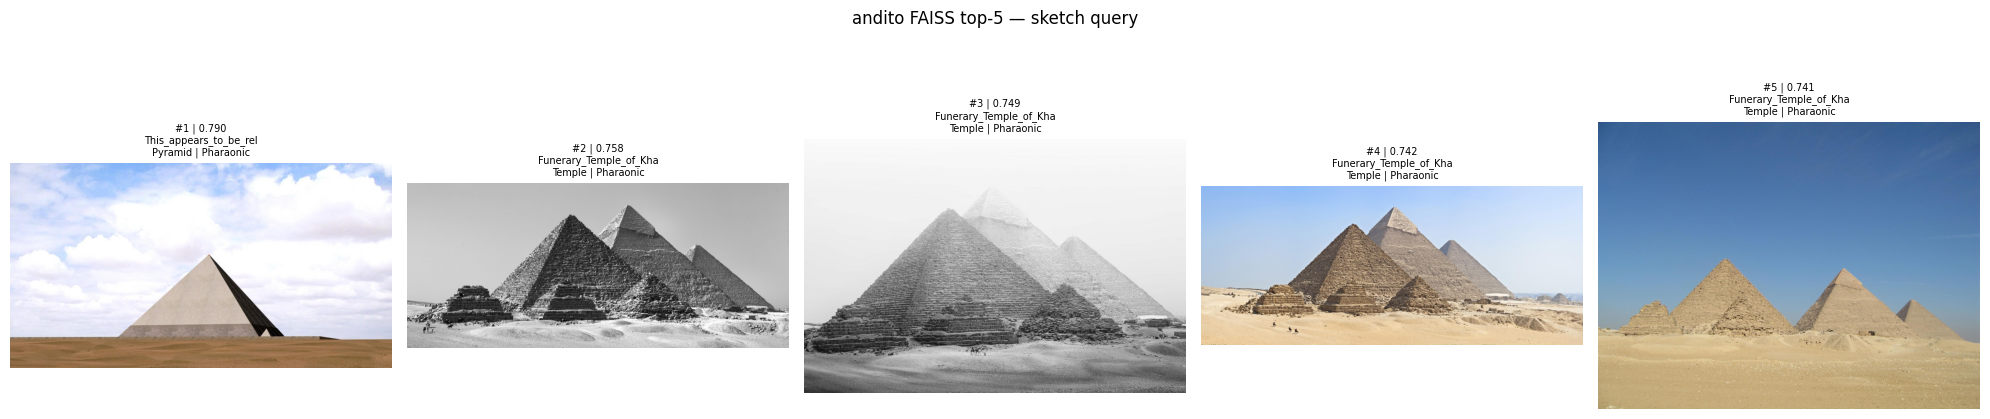

In [7]:
results = [
    {**metadata[idx], "score": float(s)}
    for s, idx in zip(faiss_scores[0], faiss_indices[0]) if idx >= 0
]

fig, axes = plt.subplots(1, len(results), figsize=(20, 5))
for i, r in enumerate(results):
    try:
        axes[i].imshow(mpimg.imread(r["image_path"]))
        axes[i].set_title(
            f"#{i+1} | {r['score']:.3f}\n"
            f"{r['landmark_name'][:22]}\n"
            f"{r['landmark_type']} | {r['historical_era']}",
            fontsize=7)
        axes[i].axis("off")
    except Exception:
        axes[i].axis("off")
plt.suptitle("andito FAISS top-5 — sketch query", fontsize=12)
plt.tight_layout()
plt.show()